<a href="https://colab.research.google.com/github/Mrinal0044/DEEP-LEARNING/blob/main/cat_vs_dog_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset


Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
 97% 768M/788M [00:07<00:00, 262MB/s]
100% 788M/788M [00:09<00:00, 87.5MB/s]


In [5]:
!unzip microsoft-catsvsdogs-dataset.zip


Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/550.jpg   
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  

In [26]:
import os
os.listdir('/content')


['.config',
 'kaggle.json',
 'MSR-LA - 3467.docx',
 'PetImages',
 'microsoft-catsvsdogs-dataset.zip',
 'readme[1].txt',
 'dataset',
 'sample_data']

In [27]:
import os

cat_path = "/content/PetImages/Cat"
dog_path = "/content/PetImages/Dog"

print("Cats:", len(os.listdir(cat_path)))
print("Dogs:", len(os.listdir(dog_path)))


Cats: 12473
Dogs: 12465


In [28]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [37]:
import os
from PIL import Image

data_dir = "/content/PetImages"

bad = 0
for category in ["Cat", "Dog"]:
    folder = os.path.join(data_dir, category)
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        try:
            img = Image.open(path)
            img = img.convert("RGB")
            img.verify()
        except:
            os.remove(path)
            bad += 1

print("Removed bad images:", bad)


Removed bad images: 0


In [38]:
import shutil, random

source_dir = "/content/PetImages"
base_dir = "/content/dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

for folder in [train_dir, test_dir]:
    for category in ["Cat", "Dog"]:
        os.makedirs(os.path.join(folder, category), exist_ok=True)

split = 0.8

for category in ["Cat", "Dog"]:
    src = os.path.join(source_dir, category)
    images = os.listdir(src)
    random.shuffle(images)

    cut = int(len(images) * split)
    train_imgs = images[:cut]
    test_imgs = images[cut:]

    for img in train_imgs:
        shutil.copy(os.path.join(src, img),
                    os.path.join(train_dir, category, img))

    for img in test_imgs:
        shutil.copy(os.path.join(src, img),
                    os.path.join(test_dir, category, img))

print("Train/Test created ✅")


Train/Test created ✅


In [39]:
import tensorflow as tf

IMG = 224
BATCH = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset/train",
    image_size=(IMG, IMG),
    batch_size=BATCH
).apply(tf.data.experimental.ignore_errors())

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset/test",
    image_size=(IMG, IMG),
    batch_size=BATCH,
    shuffle=False
).apply(tf.data.experimental.ignore_errors())


Found 24726 files belonging to 2 classes.


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Found 12225 files belonging to 2 classes.


In [40]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (x/255.0, y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (x/255.0, y)).prefetch(AUTOTUNE)


In [41]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)


Epoch 1/10
    766/Unknown 51s 57ms/step - accuracy: 0.5813 - loss: 0.6923

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


766/766 ━━━━━━━━━━━━━━━━━━━━ 67s 79ms/step - accuracy: 0.5814 - loss: 0.6922 - val_accuracy: 0.7337 - val_loss: 0.5206
Epoch 2/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 80s 105ms/step - accuracy: 0.7331 - loss: 0.5345 - val_accuracy: 0.8076 - val_loss: 0.4181
Epoch 3/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 55s 72ms/step - accuracy: 0.7970 - loss: 0.4406 - val_accuracy: 0.8645 - val_loss: 0.3135
Epoch 4/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - accuracy: 0.8422 - loss: 0.3647 - val_accuracy: 0.8941 - val_loss: 0.2554
Epoch 5/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 56s 73ms/step - accuracy: 0.8816 - loss: 0.2799 - val_accuracy: 0.9253 - val_loss: 0.1832
Epoch 6/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.9142 - loss: 0.2114 - val_accuracy: 0.9478 - val_loss: 0.1388
Epoch 7/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 57s 74ms/step - accuracy: 0.9380 - loss: 0.1603 - val_accuracy: 0.9651 - val_loss: 0.0941
Epoch 8/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.9531 - loss: 0.1227 - val_accura

In [43]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)


380/380 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9879 - loss: 0.0424
Test Accuracy: 0.9819440841674805


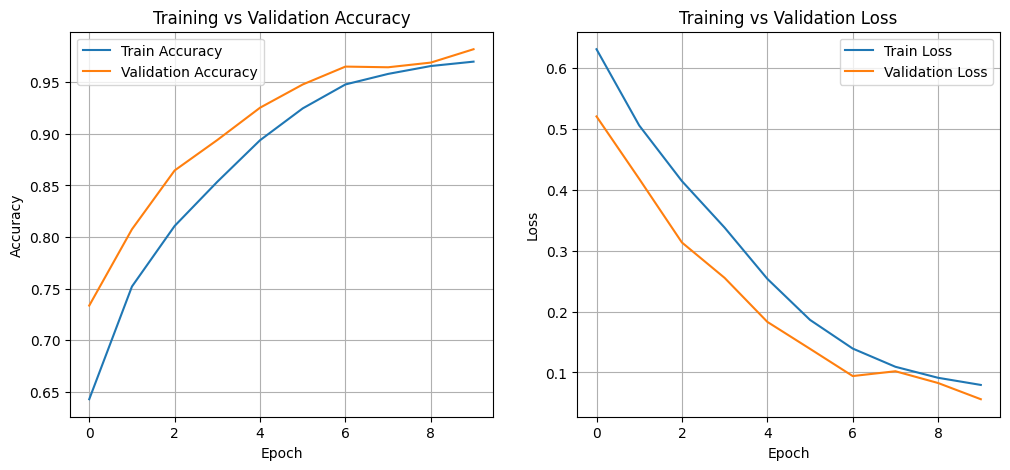

In [44]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()


In [45]:
model.save("/content/cats_dogs_model.h5")
print("Model saved ✅")


Model saved ✅


In [46]:
from google.colab import files
files.upload()


Saving Screenshot 2026-02-08 at 5.19.43 PM.png to Screenshot 2026-02-08 at 5.19.43 PM.png


{'Screenshot 2026-02-08 at 5.19.43\u202fPM.png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\xe6\x00\x00\x02x\x08\x06\x00\x00\x00)\xf5&`\x00\x00\x0cMiCCPICC Profile\x00\x00H\x89\x95W\x07XS\xc9\x16\x9e[R!\x04\x08D@J\xe8M\x10\xa9\x01\xa4\x84\xd0B\xef\x08\xa2\x12\x92\x00\xa1\xc4\x98\x10T\xec\xe8\xb2+\xb8VD\x04+\xba\n\xa2\xe8\xea\n\x88\xd8\xb0\xaf,\x8a\xdd\xb5,\x16T\x94uq]\xec\xca\x9b\x10@\x97}\xe5{\xf3}s\xe7\xbf\xff\x9c\xf9\xe7\x9cs\xe7\xde;\x03\x00\xbd\x8b/\x95\xe6\xa1\x9a\x00\xe4K\ndq!\x01\xacI)\xa9,\xd23\x80\x02\x0ch\x03=\xe0\xc2\x17\xc8\xa5\x9c\x98\x98\x08\x00\xcbp\xfb\xf7\xf2\xfa:@\x94\xed\x15\x07\xa5\xd6?\xfb\xffk\xd1\x12\x8a\xe4\x02\x00\x90\x18\x883\x84rA>\xc4?\x01\x80\xb7\n\xa4\xb2\x02\x00\x88R\xc8\x9b\xcf,\x90*q9\xc4:2\xe8 \xc4\xb5J\x9c\xa5\xc2\xadJ\x9c\xa1\xc2\x97\x06m\x12\xe2\xb8\x10?\x02\x80\xac\xce\xe7\xcb\xb2\x00\xd0\xe8\x83<\xabP\x90\x05u\xe80Z\xe0$\x11\x8a%\x10\xfbC\xec\x9b\x9f?]\x08\xf1B\x88m\xa0\r\x9c\x93\xae\xd4gg|\xa5\x93\xf57\xcd\x8c\x11M>?k\x04\xabb\x19,\xe4@\x

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
Prediction: DOG 🐶


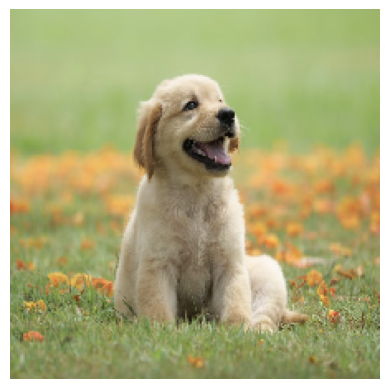

In [48]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "/content/Screenshot 2026-02-08 at 5.19.43 PM.png"   # change filename
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis("off")

if pred > 0.5:
    print("Prediction: DOG 🐶")
else:
    print("Prediction: CAT 🐱")
